# Análisis de distancia

In [35]:
import pandas as pd
import geopandas as gpd
import os, glob

In [36]:
lista_shp = glob.glob("*.shp")
lista_shp

['Cabeceras.shp', 'Vias.shp', 'Cundinamarca.shp', 'Drenajes.shp']

In [38]:
Centro_poblado = gpd.read_file(lista_shp[0])
Hidrografia = gpd.read_file(lista_shp[3])
Vial = gpd.read_file(lista_shp[1])
Limite = gpd.read_file(lista_shp[2])


In [39]:
Centro_poblado.crs.name

'WGS 84 / UTM zone 18N'

In [40]:
Hidrografia.crs.name

'WGS 84 / UTM zone 18N'

In [41]:
Vial.crs.name

'WGS 84 / UTM zone 18N'

In [42]:
Limite.crs.name

'WGS 84 / UTM zone 18N'

In [43]:
# 2. Crear una malla raster
# ------------------------------
bounds = Limite.total_bounds  # xmin, ymin, xmax, ymax
xmin, ymin, xmax, ymax = bounds

In [44]:
resolucion = 30  # metros
dist_max = 10000  # metros

In [45]:
# Ampliar un poco para cubrir dist_max
xmin -= dist_max
ymin -= dist_max
xmax += dist_max
ymax += dist_max

In [46]:
# Calcular filas y columnas
n_cols = int((xmax - xmin) / resolucion)
n_rows = int((ymax - ymin) / resolucion)

In [47]:
import numpy as np

In [48]:
# 3. Extraer coordenadas de los píxeles
# ------------------------------
x_coords = np.linspace(xmin + resolucion/2, xmax - resolucion/2, n_cols)
y_coords = np.linspace(ymax - resolucion/2, ymin + resolucion/2, n_rows)  # invertido

In [49]:
# Crear malla de puntos
xx, yy = np.meshgrid(x_coords, y_coords)
grid_points = np.vstack((xx.ravel(), yy.ravel())).T

In [50]:
# Extraer puntos de la geometría Puntos
Puntos_points = []
for geom in Centro_poblado.geometry:
    if geom.geom_type == "Point":
        Puntos_points.append((geom.x, geom.y))
    elif geom.geom_type == "MultiPoint":
        for pt in geom.geoms:
            Puntos_points.append((pt.x, pt.y))

In [51]:
# Extraer puntos de la geometría Linea
line_points = []
for geom in Hidrografia.geometry:
    if geom is not None: # Add this check to skip None geometries
        if geom.geom_type == "LineString":
            line_points.extend(list(geom.coords))
        elif geom.geom_type == "MultiLineString":
            for line in geom.geoms:
                line_points.extend(list(line.coords))

In [52]:
# Extraer puntos de la geometría Linea
Vial_points = []
for geom in Vial.geometry:
    if geom.geom_type == "LineString":
        Vial_points.extend(list(geom.coords))
    elif geom.geom_type == "MultiLineString":
        for line in geom.geoms:
            Vial_points.extend(list(line.coords))

In [53]:
Puntos_points = np.array(Puntos_points)
line_points = np.array(line_points)
Vial_points = np.array(Vial_points)

In [54]:
!pip install rasterio

In [55]:
from rasterio.transform import from_origin
from scipy.spatial import cKDTree

In [56]:
# 5. Calcular distancia euclidiana usando KDTree
# ------------------------------
tree_hidro = cKDTree(line_points)
tree_centro = cKDTree(Puntos_points)
tree_vial = cKDTree(Vial_points)
distances_hidro, _ = tree_hidro.query(grid_points, k=1)
distances_centro, _ = tree_centro.query(grid_points, k=1)
distances_vial, _ = tree_vial.query(grid_points, k=1)
distances_hidro = np.where(distances_hidro > dist_max, np.nan, distances_hidro)  # aplicar distancia máxima
distances_centro = np.where(distances_centro > dist_max, np.nan, distances_centro)  # aplicar distancia máxima
distances_vial = np.where(distances_vial > dist_max, np.nan, distances_vial)  # aplicar distancia máxima

In [57]:
# 6. Guardar como raster
# ------------------------------
dist_hidro_array = distances_hidro.reshape((n_rows, n_cols))
dist_centro_array = distances_centro.reshape((n_rows, n_cols))
dist_vial_array = distances_vial.reshape((n_rows, n_cols))


transform = from_origin(xmin, ymax, resolucion, resolucion)

In [58]:
os.getcwd()

'/content'

In [59]:
import rasterio

In [60]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

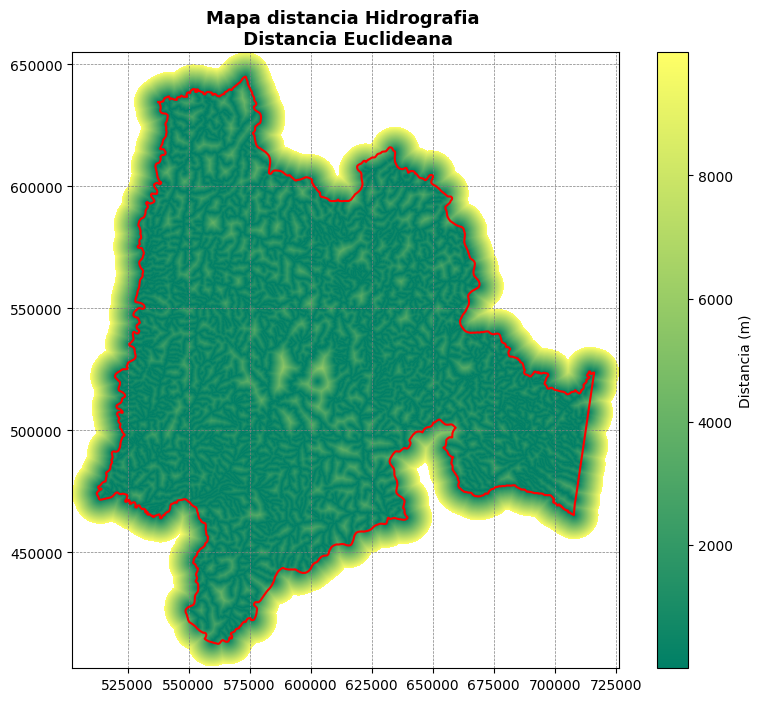

In [61]:
# Visualizar
fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(dist_hidro_array, cmap='summer',
                extent=[transform[2], transform[2] + transform[0] * dist_hidro_array.shape[1],
                        transform[5] + transform[4] * dist_hidro_array.shape[0], transform[5]],
                interpolation='nearest')
Limite.boundary.plot(ax=ax, edgecolor='red', linewidth=1.5, label="Límite de estudio")
# Mostrar coordenadas completas (no en notación científica)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

ax.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5)
plt.colorbar(img, label="Distancia (m)")
ax.set_title('Mapa distancia Hidrografia \n Distancia Euclideana',fontweight='bold',fontsize=13)
plt.axis('on')
plt.savefig('Mapa_distancia_hidrografia.jpg', dpi=300, format='jpg', bbox_inches='tight')
plt.show()

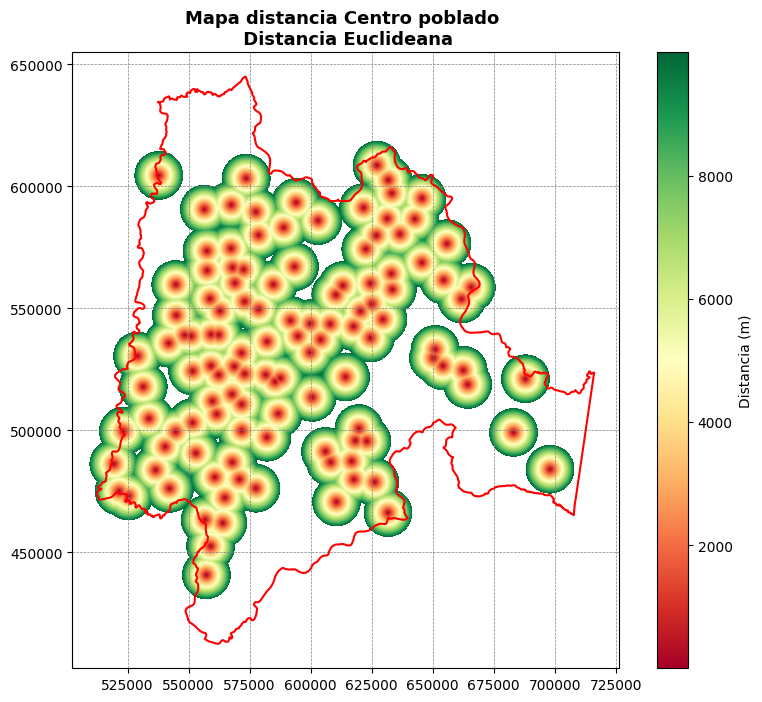

In [62]:
# Visualizar
fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(dist_centro_array, cmap='RdYlGn', interpolation='nearest',
                extent=[transform[2], transform[2] + transform[0] * dist_hidro_array.shape[1],
                        transform[5] + transform[4] * dist_hidro_array.shape[0], transform[5]]) # RdylGn
# Agregar límite del polígono
Limite.boundary.plot(ax=ax, edgecolor='red', linewidth=1.5, label="Límite de estudio")
# Mostrar coordenadas completas (no en notación científica)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5)
ax.set_title('Mapa distancia Centro poblado \n Distancia Euclideana',fontweight='bold',fontsize=13)
plt.colorbar(img, label="Distancia (m)")
plt.axis('on')
plt.savefig('Mapa_distancia_centro_poblado.jpg', dpi=300, format='jpg', bbox_inches='tight')
plt.show()

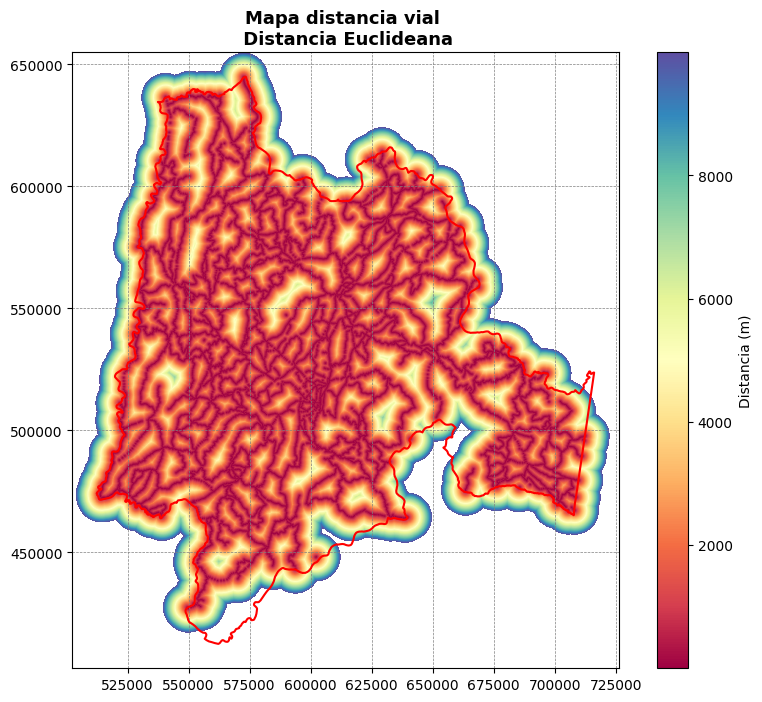

In [63]:
# Visualizar
fig, ax = plt.subplots(figsize=(10, 8))
img = plt.imshow(dist_vial_array, cmap='Spectral', interpolation='nearest',
                extent=[transform[2], transform[2] + transform[0] * dist_hidro_array.shape[1],
                        transform[5] + transform[4] * dist_hidro_array.shape[0], transform[5]],) # RdylGn
# Agregar límite del polígono
Limite.boundary.plot(ax=ax, edgecolor='red', linewidth=1.5, label="Límite de estudio")
# Mostrar coordenadas completas (no en notación científica)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5)
plt.colorbar(img, label="Distancia (m)")
ax.set_title('Mapa distancia vial \n Distancia Euclideana',fontweight='bold',fontsize=13)
plt.axis('on')
plt.savefig('Mapa_distancia_vial.jpg', dpi=300, format='jpg', bbox_inches='tight')
plt.show()

In [32]:
with rasterio.open(
    "Distancia_hidrografia.tif",
    'w',
    driver='GTiff',
    height=n_rows,
    width=n_cols,
    count=1,
    dtype='float32',
    crs=Limite.crs,
    transform=transform,
) as dst:
    dst.write(dist_hidro_array.astype('float32'), 1)

In [33]:
with rasterio.open(
    "Distancia_Centro_poblado.tif",
    'w',
    driver='GTiff',
    height=n_rows,
    width=n_cols,
    count=1,
    dtype='float32',
    crs=Limite.crs,
    transform=transform,
) as dst:
    dst.write(dist_centro_array.astype('float32'), 1)

In [34]:
with rasterio.open(
    "Distancia_vial.tif",
    'w',
    driver='GTiff',
    height=n_rows,
    width=n_cols,
    count=1,
    dtype='float32',
    crs=Limite.crs,
    transform=transform,
) as dst:
    dst.write(dist_vial_array.astype('float32'), 1)